In [1]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
input_file = r"D:\Thesis - November\Dataset\Clustering\new_70 percent\new FASTA-like per cluster 70.fasta"
output_file = r"D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_list 70.csv"

with open(input_file) as f:
    lines = [l.strip() for l in f if l.strip()]

cluster = 0
i = 0
n = len(lines)

with open(output_file, "w", newline="") as out:
    writer = csv.writer(out)
    writer.writerow(["Cluster_number", "Nanobody_id", "CDR 3 sequence"])

    while i < n:
        # Detect start of a cluster: two identical headers in a row
        if lines[i].startswith(">") and i + 1 < n and lines[i+1] == lines[i]:
            cluster += 1
            rep_id = lines[i][1:]
            i += 2

            # representative sequence
            if i < n and not lines[i].startswith(">"):
                writer.writerow([cluster, rep_id, lines[i]])
                i += 1

            # cluster members
            while i < n:
                # If next is a double header, cluster is finished
                if (lines[i].startswith(">") and 
                    i + 1 < n and lines[i+1] == lines[i]):
                    break

                if lines[i].startswith(">"):
                    nb_id = lines[i][1:]
                    seq = lines[i+1]
                    writer.writerow([cluster, nb_id, seq])
                    i += 2
                else:
                    i += 1
        else:
            i += 1

print("Done! Wrote:", output_file)


Done! Wrote: D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_list 70.csv


Get Cluster size (Number of sequences per cluster)

In [12]:
cluster_df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\cluster_list 90.csv")
cluster_df = cluster_df.drop(columns=['Label'], errors='ignore')
full_df = pd.read_csv(r"D:\Thesis - November\Dataset\new_filtered_seqs_merged.csv")
merged = cluster_df.merge(full_df[['Nanobody_id', 'Label']], on='Nanobody_id', how='left')
print(merged.columns.tolist())

stats = merged.groupby('Cluster_number').agg(
    total_sequences = ('Nanobody_id', 'count'),
    label_0 = ('Label', lambda x: (x == 0).sum()),
    label_1 = ('Label', lambda x: (x == 1).sum())
).reset_index()

stats = stats.sort_values(by="total_sequences", ascending=False)
stats.to_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\cluster_stats 90.csv", index=False)



['Cluster_number', 'Nanobody_id', 'CDR 3 sequence', 'Label']


Plots of Clusters

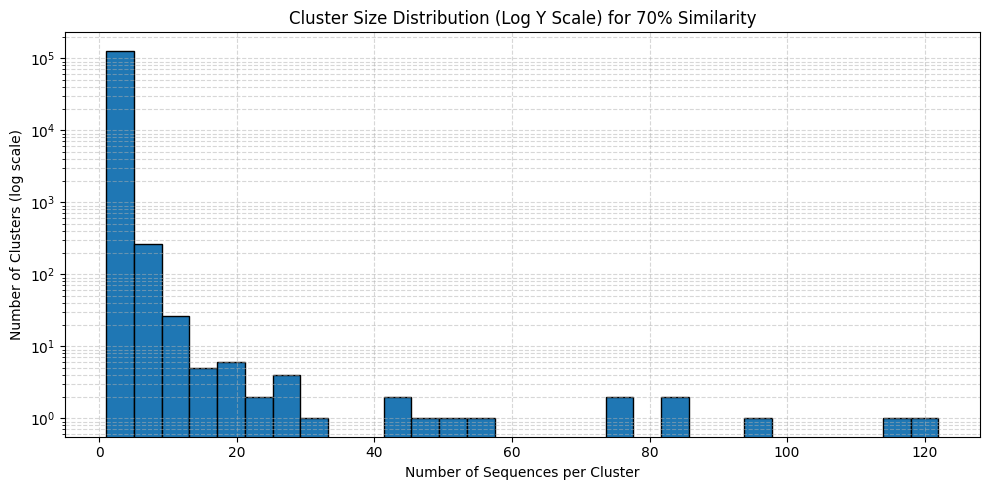

In [15]:
cluster_counts = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_stats 70.csv")
cluster_sizes = cluster_counts["total_sequences"].tolist()

plt.figure(figsize=(10, 5))
plt.hist(cluster_sizes, bins=30, edgecolor='black')
plt.yscale('log')  
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution (Log Y Scale) for 70% Similarity")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(r"D:\Thesis - November\Figures\cluster_size_distribution 70.png", dpi=300)
plt.show()

Add Label to cluster list

In [17]:
list_df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_list 70.csv")
full_df = pd.read_csv(r"D:\Thesis - November\Dataset\new_filtered_seqs_merged.csv")
merged = list_df.merge(full_df[['Nanobody_id', 'Label']], on='Nanobody_id', how='left')

merged.to_csv(r"D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_list 70.csv", index=False)

Distribution of Labels in Clusters 

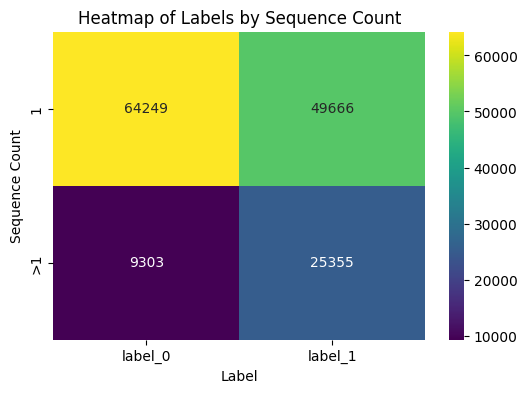

In [19]:

df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_stats 70.csv")  

# Define sequence groups
def seq_group(n):
    if n < 1:
        return "<1"
    elif n == 1:
        return "1"
    else:
        return ">1"

df["seq_group"] = df["total_sequences"].apply(seq_group)

# Prepare data for heatmap: sum label_0 and label_1 counts per group
grouped = df.groupby("seq_group")[["label_0", "label_1"]].sum()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(grouped, annot=True, fmt="d", cmap="viridis")
plt.title("Heatmap of Labels by Sequence Count")
plt.xlabel("Label")
plt.ylabel("Sequence Count")
plt.savefig(r"D:\Thesis - November\Figures\heatmap_70.png", dpi=300)
plt.show()


Graph of Clusters 

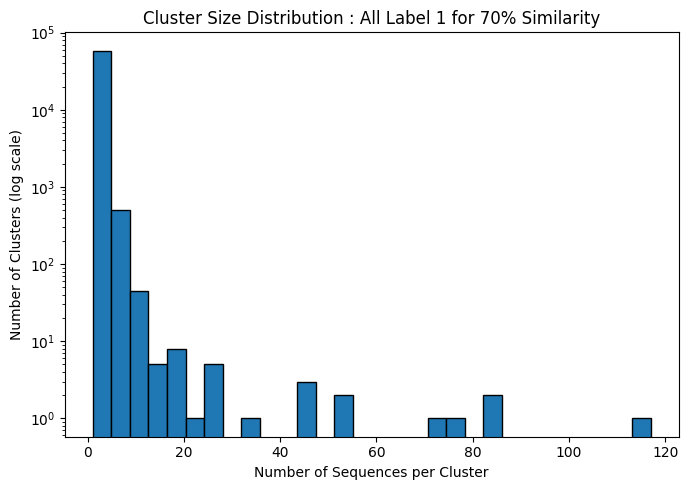

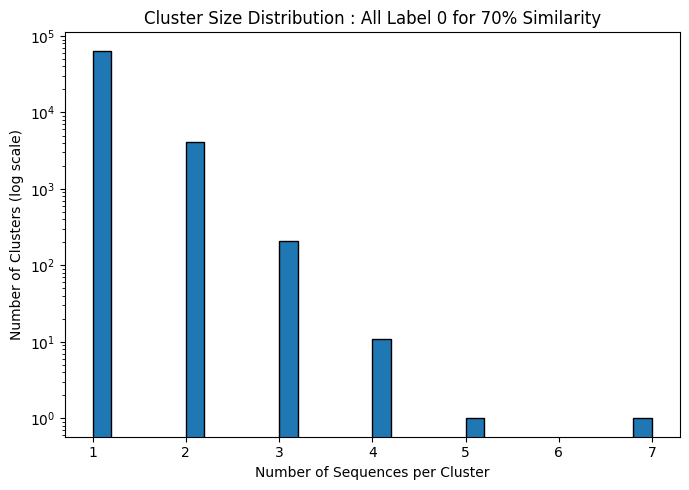

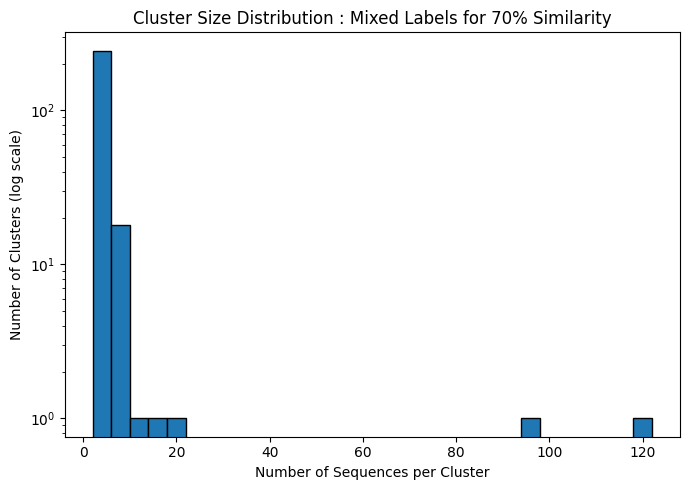

In [22]:
label_df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_70 percent\cluster_stats 70.csv")

all_label1 = label_df[(label_df["label_0"] == 0) & (label_df["label_1"] > 0)]
all_label0 = label_df[(label_df["label_1"] == 0) & (label_df["label_0"] > 0)]
mixed = label_df[(label_df["label_0"] > 0) & (label_df["label_1"] > 0)]

#All label 1
plt.figure(figsize=(7,5))
plt.hist(all_label1["total_sequences"], bins = 30, edgecolor='black')
plt.yscale('log')
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution : All Label 1 for 70% Similarity")
plt.tight_layout()
plt.savefig(r"D:\Thesis - November\Figures\all_label1_70.png", dpi=300)
plt.show()

#All label 0
plt.figure(figsize=(7,5))
plt.hist(all_label0["total_sequences"], bins = 30, edgecolor='black')
plt.yscale('log')
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution : All Label 0 for 70% Similarity")
plt.tight_layout()
plt.savefig(r"D:\Thesis - November\Figures\all_label0_70.png", dpi=300)
plt.show()

#Mixed clusters
plt.figure(figsize=(7,5))
plt.hist(mixed["total_sequences"], bins = 30, edgecolor='black')
plt.yscale('log')
plt.xlabel("Number of Sequences per Cluster")
plt.ylabel("Number of Clusters (log scale)")
plt.title("Cluster Size Distribution : Mixed Labels for 70% Similarity")
plt.tight_layout()
plt.savefig(r"D:\Thesis - November\Figures\mixed_70.png", dpi=300)
plt.show()


In [24]:

# Load your file — update the path if needed
df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\cluster_stats 90.csv")

# Compute median cluster size from the total_sequences column
median_size = df["total_sequences"].median()

print("Median cluster size:", median_size)


Median cluster size: 1.0


Train on clusters > 3 seqs

In [25]:
cluster_df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\cluster_list 90.csv")
stats_df = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\cluster_stats 90.csv")

big_clusters = stats_df.loc[stats_df["total_sequences"]>3, "Cluster_number"]

only_big_clusters = cluster_df[cluster_df["Cluster_number"].isin(big_clusters)]
print("Number of clusters with >3 seqs:", big_clusters.nunique())
print("Number of sequences in those clusters:", len(only_big_clusters))
only_big_clusters.to_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\big_clusters 90.csv", index=False)

Number of clusters with >3 seqs: 1201
Number of sequences in those clusters: 7023


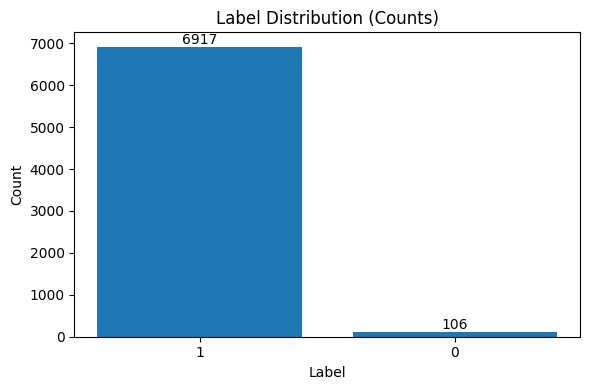

In [26]:

only_big_clusters = pd.read_csv(r"D:\Thesis - November\Dataset\Clustering\new_90 percent\big_clusters 90.csv")  

label_counts = only_big_clusters["Label"].value_counts()

# Plot
plt.figure(figsize=(6,4))
bars = plt.bar(label_counts.index.astype(str), label_counts.values)

plt.title("Label Distribution (Counts)")
plt.xlabel("Label")
plt.ylabel("Count")

for bar, count in zip(bars, label_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height(),
        f"{count}",
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()
